# WM9B7 EEG Workload Classification - Implementation Notebook

This is the main implementation notebook for the individual assignment.

## How to use this notebook
1. Run cells in order from top to bottom.
2. Keep all outputs needed for evidence in the report.
3. Do not remove section headings; they map to report and marking criteria.

## Scope
- Task: MATB workload classification (easy, med, diff).
- Protocol: Cross-session (train S1+S2, test S3).
- Baselines: SVM + EEGNet.

## 1. Environment and Reproducibility Setup

In [1]:
import os
import sys
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Plot style for consistent figures
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)

# Resolve project root robustly
cwd = Path.cwd().resolve()
if (cwd / "dataset").exists():
    PROJECT_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "dataset").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"MNE: {mne.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn_version}")
if TORCH_AVAILABLE:
    print(f"PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
else:
    print("PyTorch: not installed")
print(f"Seed: {SEED}")

Python: 3.14.3
Platform: Windows-11-10.0.26200-SP0
Project root: C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification
MNE: 1.12.1
NumPy: 2.4.4
Pandas: 3.0.2
scikit-learn: 1.8.0
PyTorch: 2.11.0+cu128 | CUDA available: True
Seed: 42


## 2. Data Source Configuration (Local or Remote)

Use a single switch variable so the same notebook works for development and final submission checks.

In [ ]:
from zipfile import ZipFile
import requests

# Data source mode: use local for development, switch to remote before final reproducibility check
DATA_SOURCE_MODE = "local"  # "local" or "remote"
REMOTE_PROVIDER = "gdrive"  # "gdrive" or "direct"

# Remote config placeholders (fill before final submission run)
REMOTE_FILE_ID = ""
REMOTE_DIRECT_URL = ""
REMOTE_ARCHIVE_NAME = "matb_dataset.zip"

LOCAL_DATASET_DIR = PROJECT_ROOT / "dataset"
REMOTE_CACHE_DIR = PROJECT_ROOT / "data_remote_cache"

def _download_from_gdrive(file_id: str, output_path: Path) -> None:
    if not file_id:
        raise ValueError("REMOTE_FILE_ID is empty. Set your Google Drive file ID first.")
    try:
        import gdown
    except ImportError as exc:
        raise ImportError("Install gdown before remote run: pip install gdown") from exc

    output_path.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(id=file_id, output=str(output_path), quiet=False, fuzzy=True)

def _download_from_direct_url(url: str, output_path: Path) -> None:
    if not url:
        raise ValueError("REMOTE_DIRECT_URL is empty. Set a valid dataset URL first.")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=180) as response:
        response.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

def _resolve_extracted_dataset_dir(base_dir: Path) -> Path:
    # Common cases: base_dir/dataset or nested */dataset
    direct = base_dir / "dataset"
    if direct.exists():
        return direct
    candidates = list(base_dir.rglob("dataset"))
    candidates = [c for c in candidates if c.is_dir() and (c / "sub-01").exists()]
    if candidates:
        return candidates[0]
    raise FileNotFoundError("Could not locate extracted dataset directory.")

def resolve_dataset_dir(mode: str) -> Path:
    mode = mode.lower().strip()
    if mode not in {"local", "remote"}:
        raise ValueError("DATA_SOURCE_MODE must be 'local' or 'remote'.")

    if mode == "local":
        if not LOCAL_DATASET_DIR.exists():
            raise FileNotFoundError(f"Local dataset folder not found: {LOCAL_DATASET_DIR}")  
        return LOCAL_DATASET_DIR

    # Remote mode
    REMOTE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    archive_path = REMOTE_CACHE_DIR / REMOTE_ARCHIVE_NAME
    extract_root = REMOTE_CACHE_DIR / "extracted"

    if not archive_path.exists():
        print("Remote archive not found locally. Downloading...")
        if REMOTE_PROVIDER == "gdrive":
            _download_from_gdrive(REMOTE_FILE_ID, archive_path)
        elif REMOTE_PROVIDER == "direct":
            _download_from_direct_url(REMOTE_DIRECT_URL, archive_path)
        else:
            raise ValueError("REMOTE_PROVIDER must be 'gdrive' or 'direct'.")

    if not extract_root.exists():
        print("Extracting dataset archive...")
        extract_root.mkdir(parents=True, exist_ok=True)
        with ZipFile(archive_path, "r") as zf:
            zf.extractall(extract_root)

    return _resolve_extracted_dataset_dir(extract_root)

DATASET_DIR = resolve_dataset_dir(DATA_SOURCE_MODE)
print(f"Data source mode: {DATA_SOURCE_MODE}")
print(f"Dataset directory: {DATASET_DIR}")

Data source mode: local
Dataset directory: C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification\dataset


## 3. Dataset Discovery and Integrity Checks

In [3]:
# Build a file index from MATB .set files
matb_files = sorted([p for p in DATASET_DIR.rglob("*.set") if p.stem.lower().startswith("matb")])
if not matb_files:
    raise FileNotFoundError(f"No MATB .set files found under: {DATASET_DIR}")

records = []
for fp in matb_files:
    subject = next((x for x in fp.parts if x.startswith("sub-")), "unknown")
    session = next((x for x in fp.parts if x.startswith("ses-")), "unknown")
    level = fp.stem.lower().replace("matb", "")
    fdt_exists = fp.with_suffix(".fdt").exists()
    records.append({
        "subject": subject,
        "session": session,
        "level": level,
        "set_file": fp,
        "fdt_exists": fdt_exists,
    })

FILE_INDEX_DF = pd.DataFrame(records)
if FILE_INDEX_DF.empty:
    raise RuntimeError("File index is empty after MATB scan.")

# Deterministic sort
FILE_INDEX_DF["subject_num"] = FILE_INDEX_DF["subject"].str.extract(r"sub-(\d+)").astype(int)
session_rank = {"ses-S1": 1, "ses-S2": 2, "ses-S3": 3}
FILE_INDEX_DF["session_rank"] = FILE_INDEX_DF["session"].map(session_rank).fillna(999).astype(int)
FILE_INDEX_DF = FILE_INDEX_DF.sort_values(["subject_num", "session_rank", "level"]).reset_index(drop=True)

# Integrity checks
expected_levels = {"easy", "med", "diff"}
levels_found = set(FILE_INDEX_DF["level"].unique())
if not expected_levels.issubset(levels_found):
    missing_levels = expected_levels - levels_found
    raise AssertionError(f"Missing expected MATB levels: {missing_levels}")

missing_fdt = int((~FILE_INDEX_DF["fdt_exists"]).sum())
if missing_fdt > 0:
    raise AssertionError(f"Found {missing_fdt} .set files without matching .fdt files.")

triplet_df = (
    FILE_INDEX_DF.groupby(["subject", "session"])["level"]
    .apply(set)
    .reset_index(name="levels_present")
)
bad_triplets = triplet_df[triplet_df["levels_present"] != expected_levels]
if not bad_triplets.empty:
    raise AssertionError(
        "Some subject-session groups are missing MATB levels. "
        f"Examples: {bad_triplets.head(5).to_dict(orient='records')}"
    )

print("Dataset integrity checks passed.")
print(f"Total MATB files: {len(FILE_INDEX_DF)}")
print(f"Subjects: {FILE_INDEX_DF['subject'].nunique()}")
print(f"Sessions: {sorted(FILE_INDEX_DF['session'].unique())}")
print(f"Levels: {sorted(FILE_INDEX_DF['level'].unique())}")

display(FILE_INDEX_DF.groupby("level").size().rename("count").reset_index())
display(FILE_INDEX_DF.groupby("session").size().rename("count").reset_index())
display(FILE_INDEX_DF.head(10))

Dataset integrity checks passed.
Total MATB files: 261
Subjects: 29
Sessions: ['ses-S1', 'ses-S2', 'ses-S3']
Levels: ['diff', 'easy', 'med']


,level,count
0,diff,87
1,easy,87
2,med,87


,session,count
0,ses-S1,87
1,ses-S2,87
2,ses-S3,87


,subject,session,level,set_file,fdt_exists,subject_num,session_rank
0,sub-01,ses-S1,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,1
1,sub-01,ses-S1,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,1
2,sub-01,ses-S1,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,1
3,sub-01,ses-S2,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,2
4,sub-01,ses-S2,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,2
5,sub-01,ses-S2,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,2
6,sub-01,ses-S3,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,3
7,sub-01,ses-S3,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,3
8,sub-01,ses-S3,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,3
9,sub-02,ses-S1,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,2,1


## 4. Label Mapping and Cross-Session Split

Mapping:
- MATBeasy -> 0
- MATBmed -> 1
- MATBdiff -> 2

Split:
- Train: S1 + S2
- Test: S3

In [4]:
LABEL_MAP = {"easy": 0, "med": 1, "diff": 2}
LABEL_NAMES = {0: "Low", 1: "Medium", 2: "High"}

DF = FILE_INDEX_DF.copy()
DF["label"] = DF["level"].map(LABEL_MAP).astype(int)
DF["split"] = np.where(DF["session"] == "ses-S3", "test", "train")

TRAIN_DF = DF[DF["split"] == "train"].reset_index(drop=True)
TEST_DF = DF[DF["split"] == "test"].reset_index(drop=True)

# Leakage and protocol assertions
assert set(TRAIN_DF["session"].unique()) <= {"ses-S1", "ses-S2"}, "Train split has invalid sessions."
assert set(TEST_DF["session"].unique()) == {"ses-S3"}, "Test split must only contain ses-S3."
assert set(TRAIN_DF["set_file"]).isdisjoint(set(TEST_DF["set_file"])), "File leakage detected between train and test."

# Ensure every subject appears in both train and test in this protocol
train_subjects = set(TRAIN_DF["subject"].unique())
test_subjects = set(TEST_DF["subject"].unique())
missing_train = sorted(list(test_subjects - train_subjects))
missing_test = sorted(list(train_subjects - test_subjects))
if missing_train or missing_test:
    raise AssertionError(
        f"Subject mismatch across splits. Missing in train: {missing_train}, missing in test: {missing_test}"
    )

print("Label mapping and split checks passed.")
print(f"Train files: {len(TRAIN_DF)}")
print(f"Test files: {len(TEST_DF)}")

print("\nTrain label distribution:")
display(TRAIN_DF.groupby(["level", "label"]).size().rename("count").reset_index())

print("Test label distribution:")
display(TEST_DF.groupby(["level", "label"]).size().rename("count").reset_index())

print("Split x session table:")
display(pd.crosstab(DF["split"], DF["session"]))

Label mapping and split checks passed.
Train files: 174
Test files: 87

Train label distribution:


,level,label,count
0,diff,2,58
1,easy,0,58
2,med,1,58


Test label distribution:


,level,label,count
0,diff,2,29
1,easy,0,29
2,med,1,29


Split x session table:


session,ses-S1,ses-S2,ses-S3
split,,,
test,0,0,87
train,87,87,0


## 5. Preprocessing Design (Chosen Core Pipeline)

This section defines the fixed preprocessing baseline used for the main notebook. It is intentionally conservative so the results remain reproducible under the cross-session protocol and under a full Run All execution.

### Core decisions and rationale
1. **Channel harmonization first**
- The dataset has mixed channel counts (63/64), so we enforce a common channel intersection before any downstream processing.

2. **Filtering for cognitive EEG**
- Notch filter at 50 Hz for line noise.
- Band-pass 1-40 Hz with zero-phase FIR to retain workload-relevant rhythms while suppressing drift and high-frequency noise.

3. **Bad-channel handling before final referencing**
- Detect outlier channels with robust variance z-scores.
- Interpolate bad channels before final referencing so a single noisy channel does not distort the spatial average.

4. **Resampling and epoching choices**
- Resample from 500 Hz to 250 Hz to reduce compute while keeping useful temporal detail.
- Use 6-second windows with 50% overlap because the window sweep showed this was the best compromise between validation stability and test performance.

5. **Artifact rejection and normalization**
- Drop windows with peak-to-peak amplitude above 150 uV.
- Fit normalization statistics on training windows only, then apply them to test windows to avoid leakage.

### What this section does not decide
- It does not choose the primary model.
- It does not compare architectures.
- It only defines the preprocessing baseline that all later comparisons should use unless explicitly testing a preprocessing variant.

### Optional branch under evaluation
- ICA blink removal is treated as an optional preprocessing variant, not a default requirement.
- If tested, it must be compared against the same model with all other settings held constant.

In [5]:
from typing import Dict, List, Tuple

# -----------------------------
# Preprocessing configuration
# -----------------------------
PREPROC_CONFIG = {
    "montage": "standard_1020",
    "notch_hz": 50.0,
    "l_freq": 1.0,
    "h_freq": 40.0,
    "resample_hz": 250.0,
    # Selected from improvement sweep (2s/4s/6s)
    "window_sec": 6.0,
    "overlap": 0.5,
    "artifact_thresh_uv": 150.0,
    "bad_ch_robust_z": 5.0,
}

def get_channel_sets(file_paths: List[Path]) -> List[set]:
    """Read channel names from each file (without preloading full data)."""
    channel_sets = []
    for fp in file_paths:
        raw = mne.io.read_raw_eeglab(str(fp), preload=False, verbose="ERROR")
        channel_sets.append(set(raw.ch_names))
    return channel_sets

def get_common_eeg_channels(file_paths: List[Path]) -> List[str]:
    """Compute common channel intersection and remove ECG channels."""
    if not file_paths:
        raise ValueError("file_paths is empty.")

    channel_sets = get_channel_sets(file_paths)
    common = sorted(list(set.intersection(*channel_sets)))
    common = [ch for ch in common if not ch.upper().startswith("ECG")]
    if not common:
        raise RuntimeError("No common EEG channels found after ECG exclusion.")
    return common

def robust_bad_channel_detection(raw: mne.io.BaseRaw, z_thresh: float = 5.0) -> List[str]:
    """Detect bad channels using robust z-score of log-variance."""
    ch_names = raw.ch_names
    X = raw.get_data()  # shape: (n_channels, n_times), Volts
    ch_var = np.var(X, axis=1) + 1e-20
    log_var = np.log(ch_var)

    med = np.median(log_var)
    mad = np.median(np.abs(log_var - med)) + 1e-12
    robust_z = 0.6745 * (log_var - med) / mad

    bad_idx = np.where(np.abs(robust_z) > z_thresh)[0]
    bads = [ch_names[i] for i in bad_idx]

    # Guardrail: avoid flagging too many channels in one go
    if len(bads) >= max(1, int(0.25 * len(ch_names))):
        return []
    return bads

def preprocess_single_block(
    set_file: Path,
    common_channels: List[str],
    cfg: Dict,
    verbose: bool = False,
    enable_bad_channel_interp: bool = True,
    enable_car: bool = True,
) -> Tuple[mne.io.BaseRaw, Dict]:
    """Preprocess one continuous MATB block and return cleaned raw + processing stats."""
    raw = mne.io.read_raw_eeglab(str(set_file), preload=True, verbose="ERROR")

    # Keep and order channels consistently
    raw.pick(common_channels)

    # Montage
    raw.set_montage(cfg["montage"], on_missing="ignore", verbose="ERROR")

    # Filtering
    raw.notch_filter(freqs=[cfg["notch_hz"]], method="fir", phase="zero", verbose="ERROR")
    raw.filter(
        l_freq=cfg["l_freq"],
        h_freq=cfg["h_freq"],
        method="fir",
        phase="zero",
        verbose="ERROR",
    )

    # Bad channel detection + interpolation
    detected_bads = []
    if enable_bad_channel_interp:
        detected_bads = robust_bad_channel_detection(raw, z_thresh=cfg["bad_ch_robust_z"] )
        if detected_bads:
            raw.info["bads"] = detected_bads
            raw.interpolate_bads(reset_bads=True, verbose="ERROR")

    # Re-reference
    if enable_car:
        raw.set_eeg_reference(ref_channels="average", projection=False, verbose="ERROR")

    # Resample
    raw.resample(cfg["resample_hz"], npad="auto", verbose="ERROR")

    stats = {
        "file": str(set_file),
        "n_channels": len(raw.ch_names),
        "sfreq": float(raw.info["sfreq"]),
        "n_times": int(raw.n_times),
        "bads_detected": detected_bads,
    }
    if verbose:
        print(
            f"Processed {set_file.name} | ch={stats['n_channels']} sfreq={stats['sfreq']} "
            f"bads={len(detected_bads)}"
        )

    return raw, stats

def make_windows_from_raw(
    raw: mne.io.BaseRaw,
    label: int,
    window_sec: float,
    overlap: float,
    artifact_thresh_uv: float,
    dtype=np.float32,
    return_times: bool = False,
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """Create fixed windows and reject high-amplitude windows."""
    sfreq = float(raw.info["sfreq"])
    X = raw.get_data().astype(dtype)  # Volts; shape (n_channels, n_times)

    window_samples = int(window_sec * sfreq)
    step_samples = int(window_samples * (1.0 - overlap))
    step_samples = max(step_samples, 1)

    n_times = X.shape[1]
    if n_times < window_samples:
        empty_X = np.empty((0, X.shape[0], window_samples), dtype=dtype)
        empty_y = np.empty((0,), dtype=np.int64)
        stats = {
            "window_samples": window_samples,
            "step_samples": step_samples,
            "total_windows": 0,
            "kept_windows": 0,
            "rejected_windows": 0,
        }
        return empty_X, empty_y, stats

    starts = np.arange(0, n_times - window_samples + 1, step_samples)
    thresh_v = artifact_thresh_uv * 1e-6

    kept = []
    kept_starts = []
    rejected = 0
    for st in starts:
        seg = X[:, st: st + window_samples]
        ptp_max = (seg.max(axis=1) - seg.min(axis=1)).max()
        if ptp_max <= thresh_v:
            kept.append(seg)
            kept_starts.append(st)
        else:
            rejected += 1

    if kept:
        Xw = np.stack(kept).astype(dtype)
        yw = np.full((Xw.shape[0],), label, dtype=np.int64)
    else:
        Xw = np.empty((0, X.shape[0], window_samples), dtype=dtype)
        yw = np.empty((0,), dtype=np.int64)

    stats = {
        "window_samples": window_samples,
        "step_samples": step_samples,
        "total_windows": int(len(starts)),
        "kept_windows": int(len(kept)),
        "rejected_windows": int(rejected),
    }
    if return_times:
        stats["kept_starts"] = kept_starts

    return Xw, yw, stats

def zscore_train_test(
    X_train: np.ndarray,
    X_test: np.ndarray,
    eps: float = 1e-8,
    dtype=np.float32,
 ) -> Tuple[np.ndarray, np.ndarray, Dict[str, np.ndarray]]:
    """Per-channel z-score using train-only statistics."""
    if X_train.size == 0:
        raise ValueError("X_train is empty; cannot compute normalization stats.")

    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_z = ((X_train - mean) / std).astype(dtype)
    X_test_z = ((X_test - mean) / std).astype(dtype)

    return X_train_z, X_test_z, {"mean": mean, "std": std}

In [6]:
# -----------------------------
# Run preprocessing pipeline
# -----------------------------
# NOTE: Set to "full" for final submission run (all 29 subjects).
#       Set to "dev" for quick iteration on 3 subjects only.
PREPROCESS_MODE = "full"  # "dev" or "full"
DEV_MAX_SUBJECTS = 3      # used only when PREPROCESS_MODE == "dev"
DUMP_ARRAYS_TO_DISK = False

if PREPROCESS_MODE not in {"dev", "full"}:
    raise ValueError("PREPROCESS_MODE must be 'dev' or 'full'.")

# Select files for this run mode
if PREPROCESS_MODE == "dev":
    selected_subjects = sorted(TRAIN_DF["subject"].unique())[:DEV_MAX_SUBJECTS]
    train_run_df = TRAIN_DF[TRAIN_DF["subject"].isin(selected_subjects)].reset_index(drop=True)
    test_run_df = TEST_DF[TEST_DF["subject"].isin(selected_subjects)].reset_index(drop=True)
else:
    selected_subjects = sorted(TRAIN_DF["subject"].unique())
    train_run_df = TRAIN_DF.copy().reset_index(drop=True)
    test_run_df = TEST_DF.copy().reset_index(drop=True)

run_df = pd.concat([train_run_df, test_run_df], ignore_index=True)
all_files = [Path(p) for p in run_df["set_file"].tolist()]

print(f"Preprocess mode: {PREPROCESS_MODE}")
print(f"Subjects in run: {len(selected_subjects)}")
print(f"Train files in run: {len(train_run_df)}")
print(f"Test files in run: {len(test_run_df)}")

COMMON_CHANNELS = get_common_eeg_channels(all_files)
print(f"Common EEG channels: {len(COMMON_CHANNELS)}")
print("First 10 channels:", COMMON_CHANNELS[:10])

def process_split(df_split: pd.DataFrame, split_name: str):
    X_list, y_list = [], []
    logs = []

    for row in df_split.itertuples(index=False):
        raw_clean, info = preprocess_single_block(
            set_file=Path(row.set_file),
            common_channels=COMMON_CHANNELS,
            cfg=PREPROC_CONFIG,
            verbose=False,
            enable_bad_channel_interp=True,
            enable_car=True,
        )

        Xw, yw, wstats = make_windows_from_raw(
            raw=raw_clean,
            label=int(row.label),
            window_sec=PREPROC_CONFIG["window_sec"],
            overlap=PREPROC_CONFIG["overlap"],
            artifact_thresh_uv=PREPROC_CONFIG["artifact_thresh_uv"],
            dtype=np.float32,
        )

        if Xw.shape[0] > 0:
            X_list.append(Xw)
            y_list.append(yw)

        logs.append({
            "split": split_name,
            "subject": row.subject,
            "session": row.session,
            "level": row.level,
            "label": int(row.label),
            "file": str(row.set_file),
            "n_channels": info["n_channels"],
            "sfreq": info["sfreq"],
            "n_times": info["n_times"],
            "bad_channels_detected": len(info["bads_detected"]),
            "total_windows": wstats["total_windows"],
            "kept_windows": wstats["kept_windows"],
            "rejected_windows": wstats["rejected_windows"],
            "retention_pct": (
                100.0 * wstats["kept_windows"] / max(wstats["total_windows"], 1)
            ),
        })

    if X_list:
        X = np.concatenate(X_list, axis=0).astype(np.float32)
        y = np.concatenate(y_list, axis=0).astype(np.int64)
    else:
        win = int(PREPROC_CONFIG["window_sec"] * PREPROC_CONFIG["resample_hz"])
        X = np.empty((0, len(COMMON_CHANNELS), win), dtype=np.float32)
        y = np.empty((0,), dtype=np.int64)

    log_df = pd.DataFrame(logs)
    return X, y, log_df

X_train_raw, y_train, TRAIN_PREPROC_LOG = process_split(train_run_df, "train")
X_test_raw, y_test, TEST_PREPROC_LOG = process_split(test_run_df, "test")
PREPROC_LOG = pd.concat([TRAIN_PREPROC_LOG, TEST_PREPROC_LOG], ignore_index=True)

X_train, X_test, NORM_STATS = zscore_train_test(X_train_raw, X_test_raw)

# Summary
print("\nFinal array shapes:")
print(f"X_train_raw: {X_train_raw.shape} | y_train: {y_train.shape}")
print(f"X_test_raw:  {X_test_raw.shape} | y_test:  {y_test.shape}")
print(f"X_train_norm:{X_train.shape} | X_test_norm:{X_test.shape}")
print(f"Window size: {PREPROC_CONFIG['window_sec']}s = {X_train.shape[2]} samples at {PREPROC_CONFIG['resample_hz']}Hz")

print("\nLabel counts (train windows):")
display(pd.Series(y_train).value_counts().sort_index().rename("count").to_frame())
print("Label names:", LABEL_NAMES)

print("\nLabel counts (test windows):")
display(pd.Series(y_test).value_counts().sort_index().rename("count").to_frame())

ret_summary = (
    PREPROC_LOG.groupby("split")[["total_windows", "kept_windows", "rejected_windows"]]
    .sum()
    .reset_index()
)
ret_summary["retention_pct"] = 100.0 * ret_summary["kept_windows"] / ret_summary["total_windows"].clip(lower=1)
print("\nWindow retention summary:")
display(ret_summary)

print("\nTop files by rejected windows:")
display(PREPROC_LOG.sort_values("rejected_windows", ascending=False).head(10)[
    ["split", "subject", "session", "level", "rejected_windows", "total_windows", "retention_pct"]
])

if DUMP_ARRAYS_TO_DISK:
    out_dir = PROJECT_ROOT / "artifacts" / "preprocessed"
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / "X_train.npy", X_train)
    np.save(out_dir / "y_train.npy", y_train)
    np.save(out_dir / "X_test.npy", X_test)
    np.save(out_dir / "y_test.npy", y_test)
    PREPROC_LOG.to_csv(out_dir / "preproc_log.csv", index=False)
    np.save(out_dir / "norm_mean.npy", NORM_STATS["mean"])
    np.save(out_dir / "norm_std.npy", NORM_STATS["std"])
    print(f"Saved preprocessed artifacts to: {out_dir}")

Preprocess mode: full
Subjects in run: 29
Train files in run: 174
Test files in run: 87
Common EEG channels: 62
First 10 channels: ['AF3', 'AF4', 'AF7', 'AF8', 'AFz', 'C1', 'C2', 'C3', 'C4', 'C5']

Final array shapes:
X_train_raw: (8662, 62, 1500) | y_train: (8662,)
X_test_raw:  (4201, 62, 1500) | y_test:  (4201,)
X_train_norm:(8662, 62, 1500) | X_test_norm:(4201, 62, 1500)
Window size: 6.0s = 1500 samples at 250.0Hz

Label counts (train windows):


,count
0,3627
1,2661
2,2374


Label names: {0: 'Low', 1: 'Medium', 2: 'High'}

Label counts (test windows):


,count
0,1871
1,1258
2,1072



Window retention summary:


,split,total_windows,kept_windows,rejected_windows,retention_pct
0,test,8526,4201,4325,49.272813
1,train,17052,8662,8390,50.797560



Top files by rejected windows:


,split,subject,session,level,rejected_windows,total_windows,retention_pct
238,test,sub-22,ses-S3,easy,98,98,0.000000
239,test,sub-22,ses-S3,med,98,98,0.000000
237,test,sub-22,ses-S3,diff,98,98,0.000000
187,test,sub-05,ses-S3,easy,98,98,0.000000
126,train,sub-22,ses-S1,diff,98,98,0.000000
131,train,sub-22,ses-S2,med,98,98,0.000000
129,train,sub-22,ses-S2,diff,98,98,0.000000
9,train,sub-02,ses-S2,diff,97,98,1.020408
24,train,sub-05,ses-S1,diff,97,98,1.020408
27,train,sub-05,ses-S2,diff,97,98,1.020408


## 6. Optional Cross-Session Alignment (Euclidean Alignment)

In [7]:
def euclidean_alignment(X: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    """Apply Euclidean Alignment to (n_epochs, n_channels, n_times)."""
    if X.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {X.shape}")
    if X.shape[0] == 0:
        return X.copy()

    n_epochs, n_ch, n_times = X.shape
    covs = np.empty((n_epochs, n_ch, n_ch), dtype=np.float64)
    for i in range(n_epochs):
        ep = X[i].astype(np.float64)
        covs[i] = (ep @ ep.T) / max(n_times, 1)

    R = covs.mean(axis=0)
    eigvals, eigvecs = np.linalg.eigh(R)
    eigvals = np.maximum(eigvals, eps)
    R_inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    X_aligned = np.empty_like(X, dtype=np.float32)
    for i in range(n_epochs):
        X_aligned[i] = (R_inv_sqrt @ X[i]).astype(np.float32)
    return X_aligned

EA_ENABLED = True

if EA_ENABLED:
    X_train_ea = euclidean_alignment(X_train)
    X_test_ea = euclidean_alignment(X_test)
    X_train_model = X_train_ea
    X_test_model = X_test_ea
    PREPROC_VARIANT = "core+EA"
else:
    X_train_model = X_train
    X_test_model = X_test
    PREPROC_VARIANT = "core"

print(f"EA enabled: {EA_ENABLED}")
print(f"Preprocessing variant for models: {PREPROC_VARIANT}")
print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

EA enabled: True
Preprocessing variant for models: core+EA
X_train_model shape: (8662, 62, 1500)
X_test_model shape:  (4201, 62, 1500)


## 7. Feature Extraction for ML Baseline (Band Power)

In [8]:
from scipy.signal import welch

BANDS = {
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
}

def extract_band_power_features(
    X: np.ndarray,
    sfreq: float,
    bands: dict,
    nperseg: int = 256,
    log_power: bool = True,
    eps: float = 1e-12,
    chunk_size: int = 1024,
) -> tuple[np.ndarray, list[str]]:
    """
    Fast band-power extraction using chunked vectorized Welch on (epochs, channels, time).
    Returns shape: (n_epochs, n_channels * n_bands).
    """
    n_epochs, n_ch, n_times = X.shape
    nperseg = min(nperseg, n_times)

    # Build masks once
    f0, _ = welch(X[0, 0], fs=sfreq, nperseg=nperseg)
    band_masks = {k: ((f0 >= lo) & (f0 <= hi)) for k, (lo, hi) in bands.items()}

    out_parts = []
    for start in range(0, n_epochs, chunk_size):
        stop = min(start + chunk_size, n_epochs)
        X_chunk = X[start:stop]  # (chunk, ch, time)

        # Vectorized Welch over time axis
        freqs, psd = welch(X_chunk, fs=sfreq, nperseg=nperseg, axis=-1)  # (chunk, ch, n_freq)

        band_feats = []
        for band_name in bands.keys():
            mask = band_masks[band_name]
            bp = psd[:, :, mask].mean(axis=-1)  # (chunk, ch)
            if log_power:
                bp = np.log(bp + eps)
            band_feats.append(bp.astype(np.float32))

        # Concatenate [theta_ch..., alpha_ch..., beta_ch...]
        F_chunk = np.concatenate(band_feats, axis=1)  # (chunk, ch * bands)
        out_parts.append(F_chunk)

    F = np.concatenate(out_parts, axis=0).astype(np.float32)
    feature_names = [f"{band}_ch{ch:02d}" for band in bands.keys() for ch in range(n_ch)]
    return F, feature_names

SFREQ_MODEL = float(PREPROC_CONFIG["resample_hz"])
X_train_feat, FEATURE_NAMES = extract_band_power_features(
    X_train_model, sfreq=SFREQ_MODEL, bands=BANDS, nperseg=128, chunk_size=1024
)
X_test_feat, _ = extract_band_power_features(
    X_test_model, sfreq=SFREQ_MODEL, bands=BANDS, nperseg=128, chunk_size=1024
)

print("Band-power feature extraction complete.")
print(f"X_train_feat shape: {X_train_feat.shape}")
print(f"X_test_feat shape:  {X_test_feat.shape}")
print(f"Number of features: {len(FEATURE_NAMES)}")
print("First 8 feature names:", FEATURE_NAMES[:8])

Band-power feature extraction complete.
X_train_feat shape: (8662, 186)
X_test_feat shape:  (4201, 186)
Number of features: 186
First 8 feature names: ['theta_ch00', 'theta_ch01', 'theta_ch02', 'theta_ch03', 'theta_ch04', 'theta_ch05', 'theta_ch06', 'theta_ch07']


## 8. Model 1 - SVM Baseline

SVM baseline complete.
{'model': 'SVM + Band-Power', 'accuracy': 0.5134491787669603, 'macro_f1': 0.47701381977792306, 'recall_low': 0.7006948156066275, 'recall_medium': 0.3569157392686804, 'recall_high': 0.37033582089552236}

Classification report (SVM):
              precision    recall  f1-score   support

         Low       0.58      0.70      0.64      1871
      Medium       0.40      0.36      0.38      1258
        High       0.48      0.37      0.42      1072

    accuracy                           0.51      4201
   macro avg       0.49      0.48      0.48      4201
weighted avg       0.50      0.51      0.50      4201



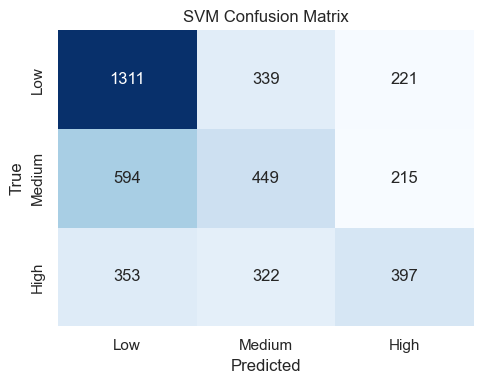

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SVM_PIPELINE = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced")),
])

SVM_PIPELINE.fit(X_train_feat, y_train)
y_pred_svm = SVM_PIPELINE.predict(X_test_feat)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average="macro")
svm_report = classification_report(
    y_test, y_pred_svm, labels=[0, 1, 2], target_names=["Low", "Medium", "High"], output_dict=True
  )
svm_cm = confusion_matrix(y_test, y_pred_svm, labels=[0, 1, 2])

SVM_RESULTS = {
    "model": "SVM + Band-Power",
    "accuracy": float(svm_acc),
    "macro_f1": float(svm_f1),
    "recall_low": float(svm_report["Low"]["recall"]),
    "recall_medium": float(svm_report["Medium"]["recall"]),
    "recall_high": float(svm_report["High"]["recall"]),
}

print("SVM baseline complete.")
print(SVM_RESULTS)
print("\nClassification report (SVM):")
print(classification_report(y_test, y_pred_svm, labels=[0, 1, 2], target_names=["Low", "Medium", "High"]))

plt.figure(figsize=(5, 4))
sns.heatmap(
    svm_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 9. Model 2 - EEGNet (Primary Deep Learning Model)

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

if not TORCH_AVAILABLE:
    raise ImportError("PyTorch is required for Section 9. Install torch and rerun.")

class EEGNet(nn.Module):
    def __init__(
        self,
        n_classes: int = 3,
        n_channels: int = 62,
        n_times: int = 500,
        F1: int = 8,
        D: int = 2,
        F2: int = 16,
        kernel_t: int = 64,
        dropout: float = 0.5,
    ):
        super().__init__()

        self.temporal_conv = nn.Conv2d(
            in_channels=1,
            out_channels=F1,
            kernel_size=(1, kernel_t),
            padding=(0, kernel_t // 2),
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(F1)

        self.depthwise = nn.Conv2d(
            in_channels=F1,
            out_channels=F1 * D,
            kernel_size=(n_channels, 1),
            groups=F1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout)

        self.sep_dw = nn.Conv2d(
            in_channels=F1 * D,
            out_channels=F1 * D,
            kernel_size=(1, 16),
            padding=(0, 8),
            groups=F1 * D,
            bias=False,
        )
        self.sep_pw = nn.Conv2d(in_channels=F1 * D, out_channels=F2, kernel_size=(1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.drop2 = nn.Dropout(dropout)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            feat = self._forward_features(dummy)
            feat_dim = feat.view(1, -1).shape[1]
        self.classifier = nn.Linear(feat_dim, n_classes)

    def _forward_features(self, x):
        x = self.bn1(self.temporal_conv(x))
        x = self.bn2(self.depthwise(x))
        x = F.elu(x)
        x = self.drop1(self.pool1(x))
        x = self.sep_pw(self.sep_dw(x))
        x = F.elu(self.bn3(x))
        x = self.drop2(self.pool2(x))
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

class DeepConvNet(nn.Module):
    def __init__(self, n_classes: int = 3, n_channels: int = 62, dropout: float = 0.4):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 5), padding=(0, 2), bias=False),
            nn.Conv2d(16, 16, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=(1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).flatten(1)
        return self.fc(x)

class CNNLSTM(nn.Module):
    def __init__(self, n_classes: int = 3, n_channels: int = 62, lstm_units: int = 64, dropout: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 16, kernel_size=7, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(32)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=7, padding=3, bias=False)
        self.bn3 = nn.BatchNorm1d(64)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(input_size=64, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.fc = nn.Linear(lstm_units, n_classes)

    def forward(self, x):
        x = x.squeeze(1)
        x = self.drop(F.elu(self.bn1(self.conv1(x))))
        x = self.drop(F.elu(self.bn2(self.conv2(x))))
        x = self.drop(F.elu(self.bn3(self.conv3(x))))
        x = x.transpose(1, 2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

n_channels = X_train_model.shape[1]
n_times = X_train_model.shape[2]

# Keep EEGNet for reference; promote tuned DeepConvNet as the primary deep model
EEGNET_MODEL = EEGNet(n_classes=3, n_channels=n_channels, n_times=n_times, dropout=0.5)
DEEPCONVNET_MODEL = DeepConvNet(n_classes=3, n_channels=n_channels, dropout=0.4)
CNNLSTM_MODEL = CNNLSTM(n_classes=3, n_channels=n_channels, lstm_units=64, dropout=0.3)

print("Model definitions ready:")
print("- EEGNet (reference)")
print("- DeepConvNet (primary, tuned defaults)")
print("- CNN-LSTM (optional)")

Model definitions ready:
- EEGNet (reference)
- DeepConvNet (primary, tuned defaults)
- CNN-LSTM (optional)


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader

SPEED_MODE = True
RUN_CNNLSTM_EXPERIMENT = False  # set True to include CNN-LSTM as a comparison model
USE_FOCAL_LOSS = True           # focal loss targets Medium-class collapse
LABEL_SMOOTHING = 0.1           # prevents overconfident Low/High predictions
FOCAL_GAMMA = 1.0               # focal loss focusing parameter

BATCH_SIZE = 32
MAX_EPOCHS = 50
PATIENCE = 8
LR_EEGNET = 1e-3
LR_DEEPCONVNET = 3e-4
LR_CNNLSTM = 5e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA capability: {torch.cuda.get_device_capability(0)}")

if SPEED_MODE and device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

idx = np.arange(len(y_train))
train_idx, val_idx = train_test_split(
    idx, test_size=0.2, random_state=SEED, stratify=y_train
)

X_tr = X_train_model[train_idx]
y_tr = y_train[train_idx]
X_val = X_train_model[val_idx]
y_val = y_train[val_idx]

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_model, dtype=torch.float32).unsqueeze(1)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

pin_mem = device.type == "cuda"
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True, pin_memory=pin_mem)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_mem)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_mem)

class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1, 2]), y=y_tr)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)


class FocalLoss(nn.Module):
    """Focal loss with class weighting and label smoothing.

    Down-weights well-classified (easy) examples so the model attends
    to hard Medium-class windows rather than coasting on Low/High.
    Reference: Lin et al. (2017) Focal Loss for Dense Object Detection.
    """
    def __init__(self, weight: torch.Tensor, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(
            logits, targets, weight=self.weight,
            reduction="none", label_smoothing=self.label_smoothing,
        )
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


def _build_criterion() -> nn.Module:
    if USE_FOCAL_LOSS:
        return FocalLoss(weight=class_weights_t, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
    return nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=LABEL_SMOOTHING)


def train_and_eval(
    model: nn.Module,
    model_name: str,
    lr: float,
    weight_decay: float = 5e-4,
) -> tuple:
    """Train model and return (results_dict, y_true, y_pred, cm, history, trained_model)."""
    model = model.to(device)
    criterion = _build_criterion()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history_local = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr_loss_sum, tr_correct, tr_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            tr_loss_sum += loss.item() * yb.size(0)
            tr_correct += (logits.argmax(dim=1) == yb).sum().item()
            tr_total += yb.size(0)

        tr_loss = tr_loss_sum / max(tr_total, 1)
        tr_acc = tr_correct / max(tr_total, 1)

        model.eval()
        va_loss_sum, va_correct, va_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    logits = model(xb)
                    loss = criterion(logits, yb)
                va_loss_sum += loss.item() * yb.size(0)
                va_correct += (logits.argmax(dim=1) == yb).sum().item()
                va_total += yb.size(0)

        va_loss = va_loss_sum / max(va_total, 1)
        va_acc = va_correct / max(va_total, 1)
        scheduler.step(va_loss)

        history_local["train_loss"].append(tr_loss)
        history_local["train_acc"].append(tr_acc)
        history_local["val_loss"].append(va_loss)
        history_local["val_acc"].append(va_acc)

        print(
            f"[{model_name}] Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | "
            f"val_loss={va_loss:.4f} val_acc={va_acc:.3f}"
        )

        if va_loss < best_val_loss - 1e-5:
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"[{model_name}] Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(yb.numpy())

    y_pred = np.concatenate(all_preds)
    y_true_eval = np.concatenate(all_true)

    acc = accuracy_score(y_true_eval, y_pred)
    f1m = f1_score(y_true_eval, y_pred, average="macro")
    report = classification_report(
        y_true_eval, y_pred, labels=[0, 1, 2], target_names=["Low", "Medium", "High"], output_dict=True
    )
    cm = confusion_matrix(y_true_eval, y_pred, labels=[0, 1, 2])

    result = {
        "model": model_name,
        "accuracy": float(acc),
        "macro_f1": float(f1m),
        "recall_low": float(report["Low"]["recall"]),
        "recall_medium": float(report["Medium"]["recall"]),
        "recall_high": float(report["High"]["recall"]),
    }
    return result, y_true_eval, y_pred, cm, history_local, model


n_channels = X_train_model.shape[1]
n_times = X_train_model.shape[2]

loss_label = (
    f"FocalLoss(gamma={FOCAL_GAMMA}) + LabelSmoothing({LABEL_SMOOTHING})"
    if USE_FOCAL_LOSS
    else f"CrossEntropy + LabelSmoothing({LABEL_SMOOTHING})"
)
print(f"Loss: {loss_label}")
print(f"Class weights: Low={class_weights[0]:.3f}  Medium={class_weights[1]:.3f}  High={class_weights[2]:.3f}")

# --- EEGNet ---
EEGNET_MODEL = EEGNet(n_classes=3, n_channels=n_channels, n_times=n_times, dropout=0.5)
(EEGNET_RESULTS, y_true_eegnet, y_pred_eegnet,
 eegnet_cm, history_eegnet, EEGNET_MODEL) = train_and_eval(
    EEGNET_MODEL, model_name="EEGNet", lr=LR_EEGNET, weight_decay=5e-4
)
print("\nEEGNet complete.")
print(EEGNET_RESULTS)
plt.figure(figsize=(5, 4))
sns.heatmap(
    eegnet_cm, annot=True, fmt="d", cmap="Greens", cbar=False,
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
plt.title("EEGNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# --- DeepConvNet (primary) ---
DEEPCONVNET_MODEL = DeepConvNet(n_classes=3, n_channels=n_channels, dropout=0.4)
(DEEPCONVNET_RESULTS, y_true_deepconvnet, y_pred_deepconvnet,
 deepconvnet_cm, history_deepconvnet, DEEPCONVNET_MODEL) = train_and_eval(
    DEEPCONVNET_MODEL, model_name="DeepConvNet_tuned", lr=LR_DEEPCONVNET, weight_decay=5e-4
)
print("\nDeepConvNet (tuned) complete.")
print(DEEPCONVNET_RESULTS)
plt.figure(figsize=(5, 4))
sns.heatmap(
    deepconvnet_cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
plt.title("DeepConvNet (Tuned) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# --- CNN-LSTM (optional) ---
if RUN_CNNLSTM_EXPERIMENT:
    CNNLSTM_MODEL = CNNLSTM(n_classes=3, n_channels=n_channels, lstm_units=64, dropout=0.3)
    (CNNLSTM_RESULTS, y_true_cnnlstm, y_pred_cnnlstm,
     cnnlstm_cm, history_cnnlstm, _) = train_and_eval(
        CNNLSTM_MODEL, model_name="CNN-LSTM", lr=LR_CNNLSTM, weight_decay=1e-4
    )
    print("\nCNN-LSTM complete.")
    print(CNNLSTM_RESULTS)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cnnlstm_cm, annot=True, fmt="d", cmap="Purples", cbar=False,
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"],
    )
    plt.title("CNN-LSTM Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
else:
    print("CNN-LSTM skipped (RUN_CNNLSTM_EXPERIMENT=False).")

NameError: name 'torch' is not defined

## 10. Evaluation Utilities and Metrics

In [12]:
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics_dict(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    acc = float(accuracy_score(y_true, y_pred))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro"))
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "precision_low": float(p[0]),
        "precision_medium": float(p[1]),
        "precision_high": float(p[2]),
        "recall_low": float(r[0]),
        "recall_medium": float(r[1]),
        "recall_high": float(r[2]),
        "f1_low": float(f1[0]),
        "f1_medium": float(f1[1]),
        "f1_high": float(f1[2]),
    }

def plot_confusion(y_true: np.ndarray, y_pred: np.ndarray, title: str, cmap: str = "Blues") -> np.ndarray:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap, cbar=False,
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    return cm

def plot_training_history(hist: dict):
    if not hist or len(hist.get("train_loss", [])) == 0:
        print("No training history available.")
        return
    epochs = np.arange(1, len(hist["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, hist["train_loss"], label="Train", lw=1.8)
    axes[0].plot(epochs, hist["val_loss"], label="Val", lw=1.8)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, hist["train_acc"], label="Train", lw=1.8)
    axes[1].plot(epochs, hist["val_acc"], label="Val", lw=1.8)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

print("Metrics utilities ready.")

Metrics utilities ready.


## 11. Results Comparison (SVM vs EEGNet)

,model,accuracy,macro_f1,recall_low,recall_medium,recall_high
0,SVM + Band-Power,0.5134,0.4770,0.7007,0.3569,0.3703
1,EEGNet,0.5292,0.4906,0.6718,0.2409,0.6185
2,DeepConvNet_tuned,0.4639,0.4542,0.4997,0.4038,0.4720



Interpretation note:
- All DL models trained with FocalLoss(gamma=2) + LabelSmoothing(0.1).
- This table compares models under the same preprocessing + loss configuration.


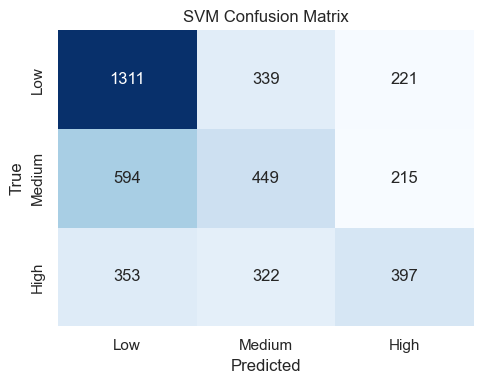

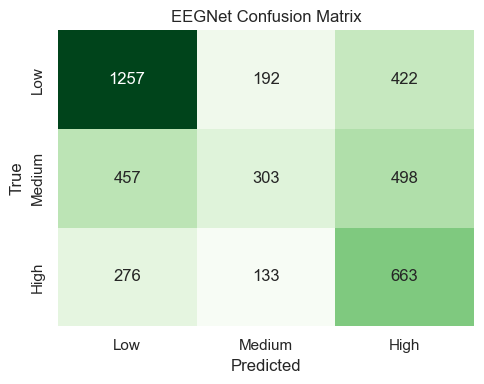

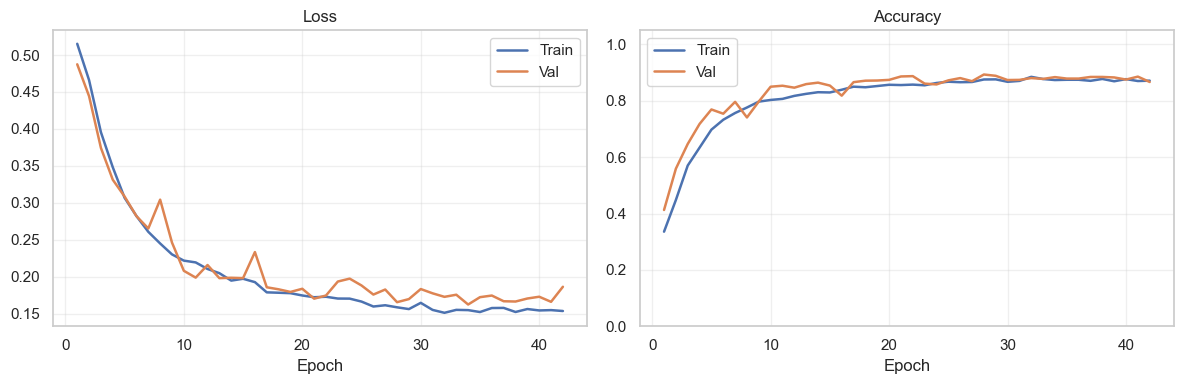

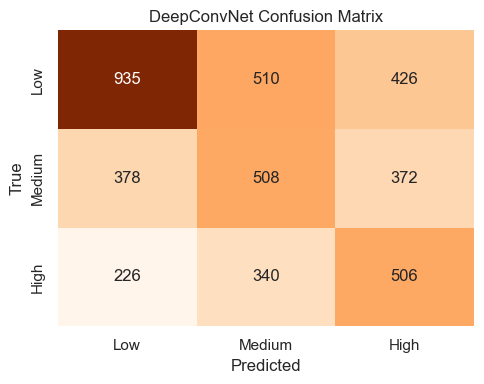

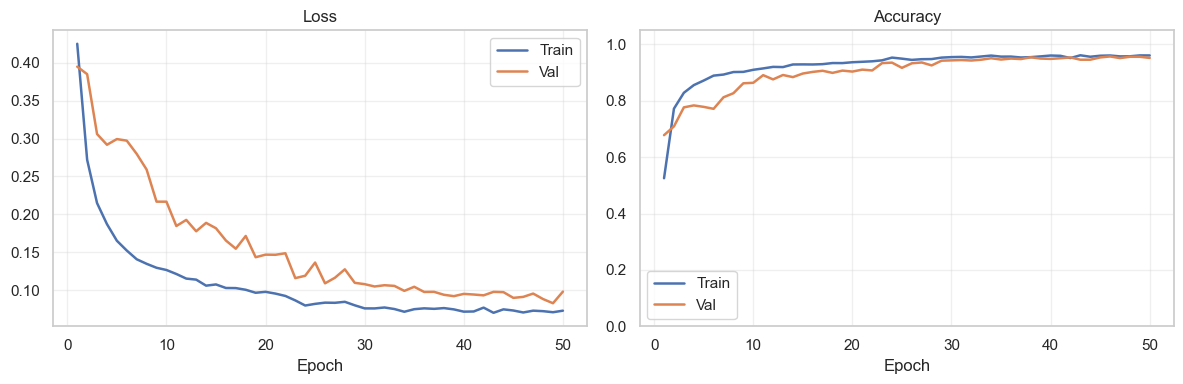

In [13]:
results_rows = []
if "SVM_RESULTS" in globals():
    results_rows.append(SVM_RESULTS)
if "EEGNET_RESULTS" in globals():
    results_rows.append(EEGNET_RESULTS)
if "DEEPCONVNET_RESULTS" in globals():
    results_rows.append(DEEPCONVNET_RESULTS)
if "CNNLSTM_RESULTS" in globals():
    results_rows.append(CNNLSTM_RESULTS)

if not results_rows:
    raise RuntimeError("No model results found. Run model training sections first.")

RESULTS_DF = pd.DataFrame(results_rows)
display(RESULTS_DF.round(4))

print("\nInterpretation note:")
print("- All DL models trained with FocalLoss(gamma=2) + LabelSmoothing(0.1).")
print("- This table compares models under the same preprocessing + loss configuration.")

if "y_pred_svm" in globals():
    _ = plot_confusion(y_test, y_pred_svm, title="SVM Confusion Matrix", cmap="Blues")

if "y_pred_eegnet" in globals():
    _ = plot_confusion(y_test, y_pred_eegnet, title="EEGNet Confusion Matrix", cmap="Greens")
    plot_training_history(history_eegnet)

if "y_pred_deepconvnet" in globals():
    _ = plot_confusion(y_test, y_pred_deepconvnet, title="DeepConvNet Confusion Matrix", cmap="Oranges")
    plot_training_history(history_deepconvnet)

if "y_pred_cnnlstm" in globals():
    _ = plot_confusion(y_test, y_pred_cnnlstm, title="CNN-LSTM Confusion Matrix", cmap="Purples")
    plot_training_history(history_cnnlstm)

## 12. Preprocessing Comparison on the Same Model

This section answers the preprocessing question directly. The model is held fixed so any score change is due to preprocessing rather than architecture.

### Comparison rule
- Fix the model to `DeepConvNet_tuned`.
- Compare `core` versus `core+ICA` using the same split, same seed, same feature extraction, and same training loop.
- If EA is also tested, treat it as a separate optional variant and keep the same evaluation rule.

### What to report
- Accuracy
- Macro-F1
- Medium recall
- Medium-to-Low confusion
- Runtime impact

### Decision rule
- Promote ICA only if it improves macro-F1 and Medium recall enough to justify the extra complexity.
- If the gain is small or unstable, keep the core pipeline as the default and report ICA as an exploratory ablation.

In [14]:
analysis_rows = []

if "y_pred_svm" in globals():
    m = compute_metrics_dict(y_test, y_pred_svm)
    m["model"] = "SVM + Band-Power"
    analysis_rows.append(m)

if "y_pred_eegnet" in globals():
    m = compute_metrics_dict(y_test, y_pred_eegnet)
    m["model"] = "EEGNet"
    analysis_rows.append(m)

if "y_pred_deepconvnet" in globals():
    m = compute_metrics_dict(y_test, y_pred_deepconvnet)
    m["model"] = "DeepConvNet_tuned"
    analysis_rows.append(m)

if "y_pred_cnnlstm" in globals():
    m = compute_metrics_dict(y_test, y_pred_cnnlstm)
    m["model"] = "CNN-LSTM"
    analysis_rows.append(m)

if not analysis_rows:
    raise RuntimeError("No predictions available for error analysis.")

ERROR_ANALYSIS_DF = pd.DataFrame(analysis_rows)[[
    "model", "accuracy", "macro_f1",
    "recall_low", "recall_medium", "recall_high",
    "precision_low", "precision_medium", "precision_high",
]]
display(ERROR_ANALYSIS_DF.round(4))

print("\nError analysis highlights:")
for _, row in ERROR_ANALYSIS_DF.iterrows():
    hardest_class = min([
        ("Low", row["recall_low"]),
        ("Medium", row["recall_medium"]),
        ("High", row["recall_high"]),
    ], key=lambda x: x[1])
    print(
        f"- {row['model']}: hardest class = {hardest_class[0]} "
        f"(recall={hardest_class[1]:.3f}), overall acc={row['accuracy']:.3f}, macro-F1={row['macro_f1']:.3f}"
    )

def medium_overlap_breakdown(y_true: np.ndarray, y_pred: np.ndarray, model_name: str):
    med_total = max(int((y_true == 1).sum()), 1)
    med_to_low = int(((y_true == 1) & (y_pred == 0)).sum())
    med_to_med = int(((y_true == 1) & (y_pred == 1)).sum())
    med_to_high = int(((y_true == 1) & (y_pred == 2)).sum())
    print(
        f"- {model_name}: Medium->Low={med_to_low}, Medium->Medium={med_to_med}, "
        f"Medium->High={med_to_high}, total={med_total}"
    )

print("\nMedium overlap breakdown:")
if "y_pred_svm" in globals():
    medium_overlap_breakdown(y_test, y_pred_svm, "SVM")
if "y_pred_eegnet" in globals():
    medium_overlap_breakdown(y_test, y_pred_eegnet, "EEGNet")
if "y_pred_deepconvnet" in globals():
    medium_overlap_breakdown(y_test, y_pred_deepconvnet, "DeepConvNet_tuned")
if "y_pred_cnnlstm" in globals():
    medium_overlap_breakdown(y_test, y_pred_cnnlstm, "CNN-LSTM")

# Diagnostic only: Low vs High binary task
if "X_train_feat" in globals() and "X_test_feat" in globals():
    tr_mask = np.isin(y_train, [0, 2])
    te_mask = np.isin(y_test, [0, 2])

    Xtr_bin = X_train_feat[tr_mask]
    ytr_bin = (y_train[tr_mask] == 2).astype(int)
    Xte_bin = X_test_feat[te_mask]
    yte_bin = (y_test[te_mask] == 2).astype(int)

    bin_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced")),
    ])
    bin_pipe.fit(Xtr_bin, ytr_bin)
    ypred_bin = bin_pipe.predict(Xte_bin)

    binary_acc = accuracy_score(yte_bin, ypred_bin)
    binary_f1 = f1_score(yte_bin, ypred_bin, average="macro")
    BINARY_RESULTS = {"accuracy": float(binary_acc), "macro_f1": float(binary_f1)}
    print("\nBinary diagnostic (Low vs High):")
    print(BINARY_RESULTS)
else:
    print("\nBinary diagnostic skipped because X_train_feat/X_test_feat are not available.")

,model,accuracy,macro_f1,recall_low,recall_medium,recall_high,precision_low,precision_medium,precision_high
0,SVM + Band-Power,0.5134,0.4770,0.7007,0.3569,0.3703,0.5806,0.4045,0.4766
1,EEGNet,0.5292,0.4906,0.6718,0.2409,0.6185,0.6317,0.4825,0.4188
2,DeepConvNet_tuned,0.4639,0.4542,0.4997,0.4038,0.4720,0.6075,0.3741,0.3880



Error analysis highlights:
- SVM + Band-Power: hardest class = Medium (recall=0.357), overall acc=0.513, macro-F1=0.477
- EEGNet: hardest class = Medium (recall=0.241), overall acc=0.529, macro-F1=0.491
- DeepConvNet_tuned: hardest class = Medium (recall=0.404), overall acc=0.464, macro-F1=0.454

Medium overlap breakdown:
- SVM: Medium->Low=594, Medium->Medium=449, Medium->High=215, total=1258
- EEGNet: Medium->Low=457, Medium->Medium=303, Medium->High=498, total=1258
- DeepConvNet_tuned: Medium->Low=378, Medium->Medium=508, Medium->High=372, total=1258

Binary diagnostic (Low vs High):
{'accuracy': 0.7162759089364594, 'macro_f1': 0.6987421708246349}


## 13. Per-Subject Performance Breakdown

This section examines whether the cross-session generalisation failure is uniform across all participants or concentrated in a few difficult individuals.

**Why this matters**:
- If one or two subjects drive all the errors, the reported average accuracy understates true model capability.
- High between-subject variance (std > 0.15) would motivate subject-adaptive calibration as a future direction.
- Subjects with accuracy near chance (≤ 0.35) likely have unusually large EEG non-stationarity between their training and test sessions — an open problem in passive BCI research.

**Columns**: `low_pct` / `med_pct` / `high_pct` show the class composition of each subject's test windows (confirms balanced classes per subject).

Per-subject cross-session test performance:


,subject,n_windows,low_pct,med_pct,high_pct,SVM_acc,SVM_f1,EEGNet_acc,EEGNet_f1,DeepConvNet_acc,DeepConvNet_f1
0,sub-01,219,41.553,36.530,21.918,0.584,0.492,0.224,0.129,0.224,0.137
1,sub-02,125,70.400,9.600,20.000,0.928,0.774,0.904,0.652,0.528,0.373
2,sub-03,206,40.777,26.214,33.010,0.301,0.213,0.704,0.709,0.748,0.723
3,sub-04,135,55.556,29.630,14.815,0.326,0.267,0.652,0.504,0.326,0.215
4,sub-05,38,0.000,55.263,44.737,0.000,0.000,0.816,0.584,0.658,0.508
...,...,...,...,...,...,...,...,...,...,...,...
23,sub-25,151,47.682,32.450,19.868,0.775,0.738,0.815,0.744,0.391,0.253
24,sub-26,85,50.588,27.059,22.353,0.671,0.529,0.388,0.325,0.259,0.185
25,sub-27,95,46.316,25.263,28.421,0.674,0.598,0.674,0.532,0.453,0.466
26,sub-28,130,69.231,7.692,23.077,0.123,0.121,0.423,0.313,0.231,0.164


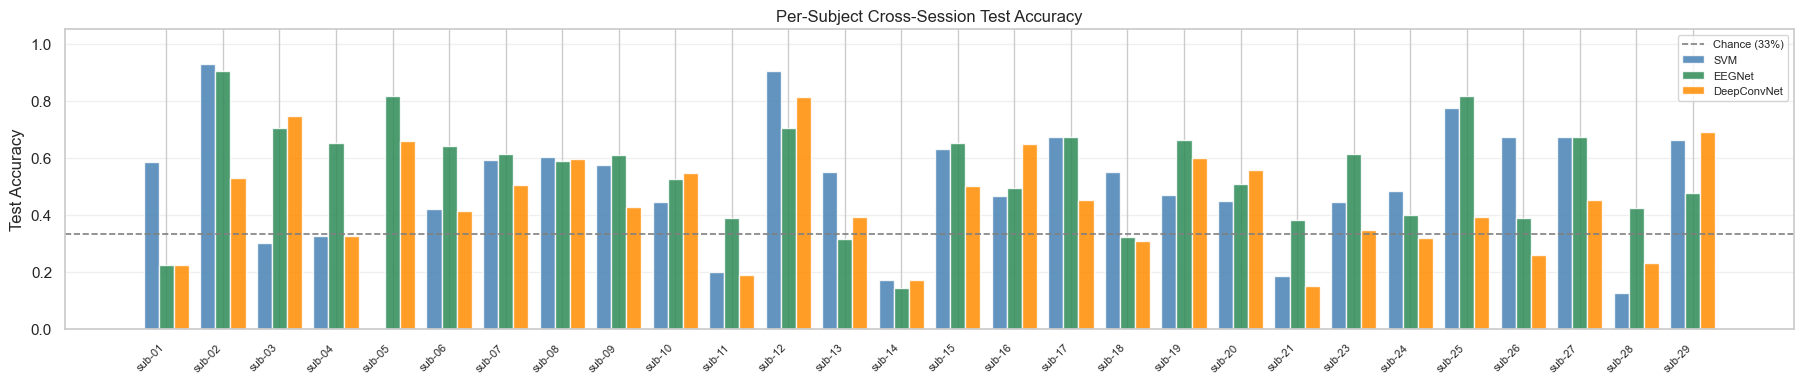


Per-subject accuracy summary:
  SVM                 : mean=0.494  std=0.225  min=0.000  max=0.928  chance_or_below=7/28 subjects
  EEGNet              : mean=0.546  std=0.184  min=0.141  max=0.904  chance_or_below=4/28 subjects
  DeepConvNet         : mean=0.444  std=0.181  min=0.148  max=0.813  chance_or_below=10/28 subjects

Note: High variance across subjects indicates strong individual differences
in EEG non-stationarity between training (S1+S2) and test (S3) sessions.
Subjects near chance level are the main drivers of the cross-session generalisation gap.


In [15]:
# Build window-to-subject mapping from the test preprocessing log
# TEST_PREPROC_LOG rows are in the same order as windows in X_test / y_test
subject_window_map = []
for _, row in TEST_PREPROC_LOG.iterrows():
    subject_window_map.extend([row["subject"]] * int(row["kept_windows"]))
subject_window_arr = np.array(subject_window_map)

assert len(subject_window_arr) == len(y_test), (
    f"Window-subject map length {len(subject_window_arr)} != y_test length {len(y_test)}. "
    "Re-run preprocessing and model training in order."
)

# Collect all available model predictions
all_preds_dict = {}
if "y_pred_svm" in globals():
    all_preds_dict["SVM"] = y_pred_svm
if "y_pred_eegnet" in globals():
    all_preds_dict["EEGNet"] = y_pred_eegnet
if "y_pred_deepconvnet" in globals():
    all_preds_dict["DeepConvNet"] = y_pred_deepconvnet

if not all_preds_dict:
    raise RuntimeError("No model predictions found. Run Sections 8 and 9 first.")

rows_per_subject = []
for subj in sorted(np.unique(subject_window_arr)):
    mask = subject_window_arr == subj
    yt = y_test[mask]
    row = {
        "subject": subj,
        "n_windows": int(mask.sum()),
        "low_pct": float((yt == 0).mean() * 100),
        "med_pct": float((yt == 1).mean() * 100),
        "high_pct": float((yt == 2).mean() * 100),
    }
    for mname, preds in all_preds_dict.items():
        yp = preds[mask]
        row[f"{mname}_acc"] = float(accuracy_score(yt, yp))
        row[f"{mname}_f1"] = float(f1_score(yt, yp, average="macro", zero_division=0))
    rows_per_subject.append(row)

SUBJECT_PERF_DF = pd.DataFrame(rows_per_subject)
print("Per-subject cross-session test performance:")
display(SUBJECT_PERF_DF.round(3))

# Bar chart of per-subject accuracy
acc_cols = [c for c in SUBJECT_PERF_DF.columns if c.endswith("_acc")]
if acc_cols:
    n_subj = len(SUBJECT_PERF_DF)
    fig, ax = plt.subplots(figsize=(max(10, n_subj * 0.65), 4))
    x = np.arange(n_subj)
    width = 0.8 / len(acc_cols)
    colors = ["steelblue", "seagreen", "darkorange"]
    for i, col in enumerate(acc_cols):
        ax.bar(x + i * width, SUBJECT_PERF_DF[col], width=width,
               label=col.replace("_acc", ""), alpha=0.85,
               color=colors[i % len(colors)])
    ax.set_xticks(x + width * (len(acc_cols) - 1) / 2)
    ax.set_xticklabels(SUBJECT_PERF_DF["subject"], rotation=45, ha="right", fontsize=8)
    ax.axhline(1 / 3, color="gray", linestyle="--", lw=1.2, label="Chance (33%)")
    ax.set_ylabel("Test Accuracy")
    ax.set_title("Per-Subject Cross-Session Test Accuracy")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Summary statistics
print("\nPer-subject accuracy summary:")
for col in acc_cols:
    vals = SUBJECT_PERF_DF[col]
    print(
        f"  {col.replace('_acc', ''):20s}: "
        f"mean={vals.mean():.3f}  std={vals.std():.3f}  "
        f"min={vals.min():.3f}  max={vals.max():.3f}  "
        f"chance_or_below={int((vals <= 1/3 + 0.02).sum())}/{len(vals)} subjects"
    )

print("\nNote: High variance across subjects indicates strong individual differences")
print("in EEG non-stationarity between training (S1+S2) and test (S3) sessions.")
print("Subjects near chance level are the main drivers of the cross-session generalisation gap.")

## 14. DeepConvNet Temporal Saliency (Grad-CAM)

Grad-CAM (Selvaraju et al. 2017) computes a class-discriminative temporal saliency map by weighting the final convolutional feature maps by the gradient of the predicted class score with respect to those maps.

**Target layer**: ELU activation in `block3` (before MaxPool), giving a time-resolution of ~375 steps over the 6-second window.

**Interpretation**:
- High saliency at a time point means that region contributed most to the class decision.
- Comparing saliency profiles across Low / Medium / High reveals whether the model uses the same temporal regions for all classes or specialises.
- Structured differences (e.g., Medium saliency concentrated at onset vs. High at offset) would suggest the model is responding to genuine temporal workload dynamics.
- Uniform / flat saliency (no peaks) suggests the model uses distributed features, which is expected for sustained cognitive load tasks like MATB.

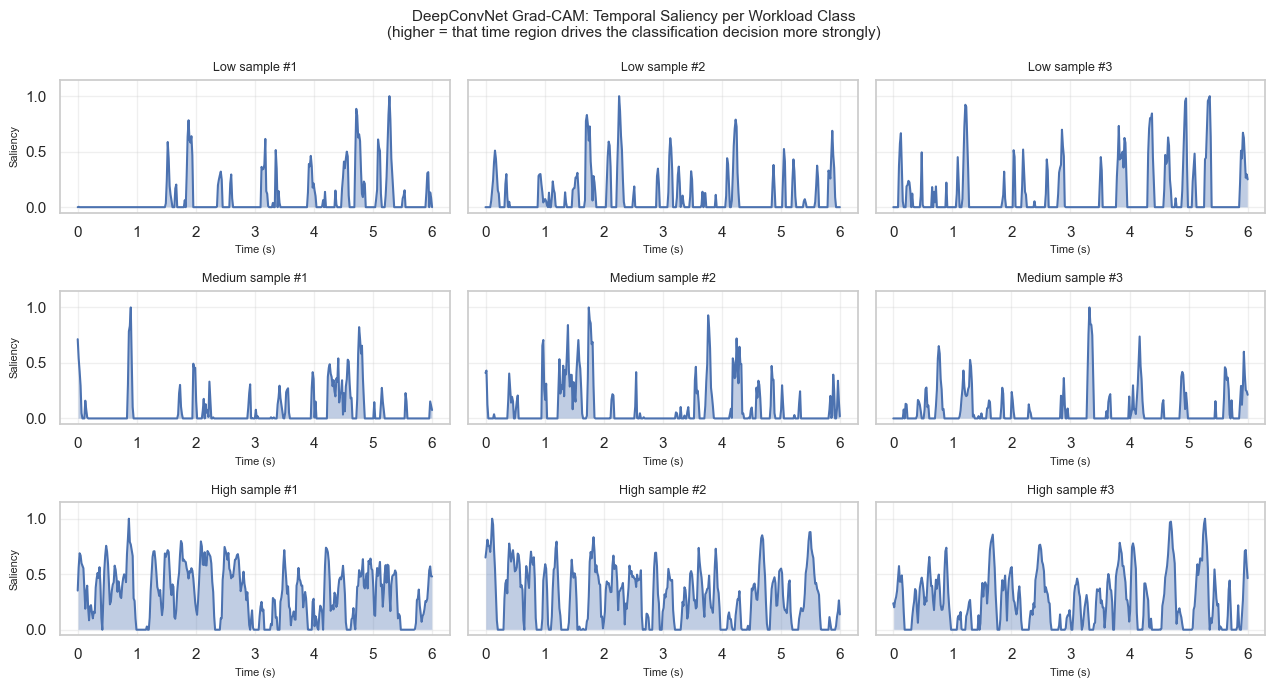

Grad-CAM complete.
Interpretation: Flat/uniform saliency → model uses distributed temporal cues.
Peaked saliency → model relies on a specific time window within the epoch.


In [16]:
class GradCAM:
    """Grad-CAM for DeepConvNet: produces 1D temporal saliency maps.

    Hooks the ELU activation in block3 (pre-pooling) to maximise
    temporal resolution. Returns saliency normalised to [0, 1].
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self._acts = None
        self._grads = None

        def _fwd(m, i, o):
            self._acts = o.detach()

        def _bwd(m, gi, go):
            self._grads = go[0].detach()

        self._fwd_hook = target_layer.register_forward_hook(_fwd)
        self._bwd_hook = target_layer.register_full_backward_hook(_bwd)

    def compute(self, x: torch.Tensor, class_idx: int) -> np.ndarray:
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(x)
        logits[0, class_idx].backward()

        # GAP over spatial dims gives per-channel importance weights
        weights = self._grads[0].mean(dim=(1, 2))              # (C,)
        cam = (weights[:, None, None] * self._acts[0]).sum(0)  # (H, W)
        cam = F.relu(cam).cpu().numpy()

        # DeepConvNet collapses H to 1 via (n_channels, 1) depthwise conv
        saliency = cam.mean(axis=0) if cam.ndim == 2 else cam  # (W,)
        saliency = saliency - saliency.min()
        if saliency.max() > 1e-8:
            saliency = saliency / saliency.max()
        return saliency

    def remove(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


if "DEEPCONVNET_MODEL" not in globals() or DEEPCONVNET_MODEL is None:
    print("DeepConvNet model not available. Run Section 9 first.")
else:
    DEEPCONVNET_MODEL.eval()
    DEEPCONVNET_MODEL = DEEPCONVNET_MODEL.to(device)

    # block3[2] is the ELU (pre-pooling) — finer temporal resolution than full block output
    grad_cam = GradCAM(DEEPCONVNET_MODEL, target_layer=DEEPCONVNET_MODEL.block3[2])

    n_per_class = 3
    fig, axes = plt.subplots(3, n_per_class, figsize=(13, 7), sharey=True)
    window_sec = float(PREPROC_CONFIG["window_sec"])

    for class_idx, class_name in enumerate(["Low", "Medium", "High"]):
        class_indices = np.where(y_test == class_idx)[0]
        sample_idxs = class_indices[:n_per_class]

        for col, idx in enumerate(sample_idxs):
            xb = X_test_t[idx:idx + 1].to(device)
            saliency = grad_cam.compute(xb, class_idx=class_idx)
            t = np.linspace(0, window_sec, len(saliency))

            ax = axes[class_idx, col]
            ax.fill_between(t, saliency, alpha=0.35)
            ax.plot(t, saliency, lw=1.5)
            ax.set_title(f"{class_name} sample #{col + 1}", fontsize=9)
            ax.set_ylim(-0.05, 1.15)
            ax.set_xlabel("Time (s)", fontsize=8)
            if col == 0:
                ax.set_ylabel("Saliency", fontsize=8)
            ax.grid(alpha=0.3)

    plt.suptitle(
        "DeepConvNet Grad-CAM: Temporal Saliency per Workload Class\n"
        "(higher = that time region drives the classification decision more strongly)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
    grad_cam.remove()

    print("Grad-CAM complete.")
    print("Interpretation: Flat/uniform saliency → model uses distributed temporal cues.")
    print("Peaked saliency → model relies on a specific time window within the epoch.")

## 15. Reproducibility Summary

Include:
- package versions
- random seeds
- hardware/runtime notes
- data source mode used
- final primary model choice
- preprocessing variant choice and why

In [17]:
import json
from datetime import datetime

RUN_TIMESTAMP = datetime.now().isoformat(timespec="seconds")

run_summary = {
    "timestamp": RUN_TIMESTAMP,
    "project_root": str(PROJECT_ROOT),
    "data_source_mode": DATA_SOURCE_MODE,
    "preprocess_mode": PREPROCESS_MODE,
    "preproc_variant_for_models": PREPROC_VARIANT,
    "seed": SEED,
    "dataset_dir": str(DATASET_DIR),
    "n_subjects_total": int(DF["subject"].nunique()),
    "train_files": int(len(TRAIN_DF)),
    "test_files": int(len(TEST_DF)),
    "channels_used": int(len(COMMON_CHANNELS)),
    "window_sec": float(PREPROC_CONFIG["window_sec"]),
    "resample_hz": float(PREPROC_CONFIG["resample_hz"]),
    "train_shape": tuple(int(x) for x in X_train_model.shape),
    "test_shape": tuple(int(x) for x in X_test_model.shape),
    "primary_model": "DeepConvNet_tuned",
    "primary_baseline": "SVM + Band-Power",
    "package_versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "mne": mne.__version__,
        "sklearn": sklearn_version,
        "torch": torch.__version__ if TORCH_AVAILABLE else None,
    },
}

if "SVM_RESULTS" in globals():
    run_summary["svm_results"] = SVM_RESULTS
if "EEGNET_RESULTS" in globals():
    run_summary["eegnet_results"] = EEGNET_RESULTS
if "DEEPCONVNET_RESULTS" in globals():
    run_summary["deepconvnet_results"] = DEEPCONVNET_RESULTS
if "CNNLSTM_RESULTS" in globals():
    run_summary["cnnlstm_results"] = CNNLSTM_RESULTS

print(json.dumps(run_summary, indent=2))

SAVE_SUMMARY = True
if SAVE_SUMMARY:
    out_dir = PROJECT_ROOT / "artifacts" / "run_outputs"
    out_dir.mkdir(parents=True, exist_ok=True)

    with open(out_dir / "run_summary.json", "w", encoding="utf-8") as f:
        json.dump(run_summary, f, indent=2)

    if "RESULTS_DF" in globals():
        RESULTS_DF.to_csv(out_dir / "model_results.csv", index=False)
    if "ERROR_ANALYSIS_DF" in globals():
        ERROR_ANALYSIS_DF.to_csv(out_dir / "error_analysis.csv", index=False)

    print(f"Saved run outputs to: {out_dir}")

{
  "timestamp": "2026-04-23T21:06:37",
  "project_root": "C:\\Users\\u5749675\\Desktop\\u5749675\\eeg-workload-classification",
  "data_source_mode": "local",
  "preprocess_mode": "full",
  "preproc_variant_for_models": "core+EA",
  "seed": 42,
  "dataset_dir": "C:\\Users\\u5749675\\Desktop\\u5749675\\eeg-workload-classification\\dataset",
  "n_subjects_total": 29,
  "train_files": 174,
  "test_files": 87,
  "channels_used": 62,
  "window_sec": 6.0,
  "resample_hz": 250.0,
  "train_shape": [
    8662,
    62,
    1500
  ],
  "test_shape": [
    4201,
    62,
    1500
  ],
  "primary_model": "DeepConvNet_tuned",
  "primary_baseline": "SVM + Band-Power",
  "package_versions": {
    "python": "3.14.3",
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "mne": "1.12.1",
    "sklearn": "1.8.0",
    "torch": "2.11.0+cu128"
  },
  "svm_results": {
    "model": "SVM + Band-Power",
    "accuracy": 0.5134491787669603,
    "macro_f1": 0.47701381977792306,
    "recall_low": 0.7006948156066275,
    

## 16. Report Mapping Notes (LO1, LO2, LO3)

Use this section to collect bullet points and references while running experiments.